# <p style="font-family: Cambria; text-align: center; font-size: 44px;">III. PRESCRIPTIVE ANALYSIS (Q16-Q30)</p>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Team2_PythonPioneers_Cardiac_Cleaned_Data.csv")
print(df.shape)

(2008, 210)


In [2]:
# Show very small p-values as "<0.001"
def p_text(p):
    if p < 0.001:
        return "<0.001"
    return round(float(p), 3)

# Chi-square test: is the outcome rate different between groups?
def chi_square(group_col, outcome_col, data):
    table = pd.crosstab(data[group_col], data[outcome_col])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    return p_text(p)

# Fisher test for two groups: returns odds ratio and p-value
def fisher(flag_col, outcome_col, data):
    table = pd.crosstab(data[flag_col], data[outcome_col])
    odds_ratio, p = stats.fisher_exact(table.values)
    return round(float(odds_ratio), 2), p_text(p)

# Mann-Whitney test: are the values different in patients who died vs survived?
def mann_whitney(value_col, outcome_col, data):
    died = data.loc[data[outcome_col] == 1, value_col].dropna()
    survived = data.loc[data[outcome_col] == 0, value_col].dropna()
    u, p = stats.mannwhitneyu(died, survived)
    return round(float(died.median()), 2), round(float(survived.median()), 2), p_text(p)

# 1 = patient died in hospital
df["in_hospital_death"] = (df["outcome_during_hospitalization"] == "Dead").astype(int)

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q16. Acute kidney failure vs CKD – Do patients with acute kidney failure during hospitalization have different length of stay and mortality outcomes compared with patients who have chronic kidney disease alone, both conditions, or neither?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>acute_renal_failure, moderate_to_severe_chronic_kidney_disease, dischargeday, death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Kidney dysfunction is an important complication in patients with heart failure because the heart and kidneys strongly influence each other. Chronic kidney disease represents long-standing kidney impairment, while acute kidney failure represents a sudden deterioration during the patient's illness. We divide patients into four groups: neither condition, CKD only, acute kidney failure only, and both conditions. We then compare length of hospital stay and 28-day mortality across these groups to determine whether acute kidney failure, either alone or combined with CKD, identifies patients with a greater observed hospital and mortality burden.</b></i></p>

,Patients,Avg_Length_of_Stay,Median_Length_of_Stay,Deaths,Mortality_Rate,Mortality_Rate_%
Kidney_Group,,,,,,
Acute Failure Only,4,8.25,9.5,1,0.25,25.00
Both,3,5.67,6.0,1,0.33,33.33
CKD Only,471,10.96,9.0,18,0.04,3.82
Neither,1530,8.96,7.0,17,0.01,1.11


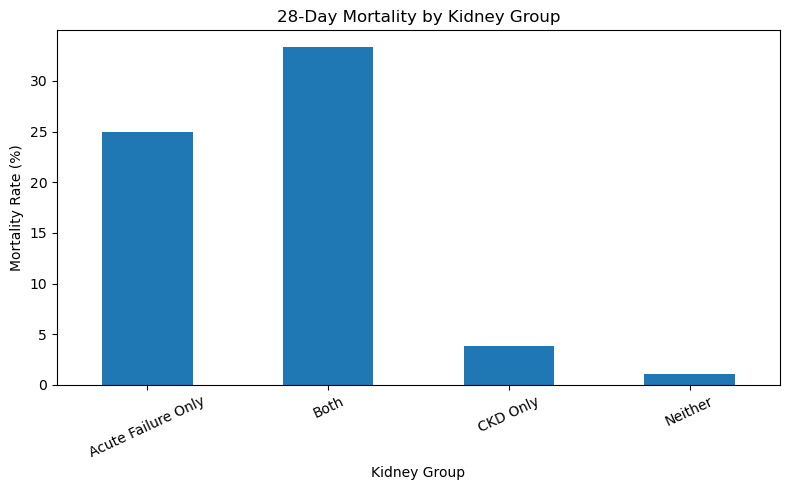

In [3]:
# Q16: Acute kidney failure vs CKD

q16 = df[
    [
        "inpatient_number",
        "moderate_to_severe_chronic_kidney_disease",
        "acute_renal_failure",
        "dischargeday",
        "death_within_28_days"
    ]
].copy()

# Convert kidney indicators to numeric
q16["CKD"] = pd.to_numeric(
    q16["moderate_to_severe_chronic_kidney_disease"],
    errors="coerce"
).fillna(0)

q16["AKI"] = pd.to_numeric(
    q16["acute_renal_failure"],
    errors="coerce"
).fillna(0)

# Create kidney groups
q16["Kidney_Group"] = np.select(
    [
        (q16["CKD"] == 0) & (q16["AKI"] == 0),
        (q16["CKD"] > 0) & (q16["AKI"] == 0),
        (q16["CKD"] == 0) & (q16["AKI"] > 0),
        (q16["CKD"] > 0) & (q16["AKI"] > 0)
    ],
    [
        "Neither",
        "CKD Only",
        "Acute Failure Only",
        "Both"
    ],
    default="Unknown"
)

q16_summary = q16.groupby("Kidney_Group").agg(
    Patients=("inpatient_number", "count"),
    Avg_Length_of_Stay=("dischargeday", "mean"),
    Median_Length_of_Stay=("dischargeday", "median"),
    Deaths=("death_within_28_days", "sum"),
    Mortality_Rate=("death_within_28_days", "mean")
)

q16_summary["Mortality_Rate_%"] = (
    q16_summary["Mortality_Rate"] * 100
).round(2)

display(q16_summary.round(2))

# Chart
q16_summary["Mortality_Rate_%"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("28-Day Mortality by Kidney Group")
plt.xlabel("Kidney Group")
plt.ylabel("Mortality Rate (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients with COPD and/or type II respiratory failure had clearly higher CO₂ levels, with an average of 39.56 compared with 34.73 in patients without these respiratory conditions. Oxygen therapy was also more common: 99.05% of the respiratory-disease group received oxygen therapy compared with 93.67% of patients without respiratory disease. However, 6-month readmission was not higher in the respiratory-disease group; it was 37.22% compared with 38.73% in patients without respiratory disease.<br><b>What this means:</b> COPD and type II respiratory failure identify patients with greater respiratory burden, especially higher CO₂ and greater oxygen use, but in this dataset they do not appear to identify a group with higher 6-month readmission based on the descriptive rates alone.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q17. Respiratory disease – Are COPD and type II respiratory failure associated with higher CO₂ levels, greater oxygen requirements and higher readmission rates?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>chronic_obstructive_pulmonary_disease, type_ii_respiratory_failure, partial_pressure_of_carbon_dioxide, oxygen_inhalation, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Heart failure and respiratory disease can place additional stress on each other. COPD can reduce effective ventilation, while type II respiratory failure is characterized by difficulty removing carbon dioxide from the body. Patients with these respiratory conditions may therefore have higher CO₂ levels, greater need for supplemental oxygen and more complicated recovery after discharge. We compare patients with COPD and/or type II respiratory failure with patients without these conditions to determine whether respiratory disease is associated with greater physiological burden and higher observed readmission.</b></i></p>

In [4]:
# Q17: COPD / Type II respiratory failure

q17 = df[
    [
        "inpatient_number",
        "chronic_obstructive_pulmonary_disease",
        "type_ii_respiratory_failure",
        "partial_pressure_of_carbon_dioxide",
        "oxygen_inhalation",
        "re_admission_within_6_months"
    ]
].copy()

copd = pd.to_numeric(
    q17["chronic_obstructive_pulmonary_disease"],
    errors="coerce"
).fillna(0)

resp_failure = pd.to_numeric(
    q17["type_ii_respiratory_failure"],
    errors="coerce"
).fillna(0)

q17["Respiratory_Group"] = np.where(
    (copd > 0) | (resp_failure > 0),
    "COPD / Type II Respiratory Failure",
    "No Respiratory Disease"
)

q17_summary = q17.groupby("Respiratory_Group").agg(
    Patients=("inpatient_number", "count"),
    Avg_CO2=("partial_pressure_of_carbon_dioxide", "mean"),
    Median_CO2=("partial_pressure_of_carbon_dioxide", "median"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q17_summary["Readmission_Rate_%"] = (
    q17_summary["Readmission_Rate"] * 100
).round(2)

display(q17_summary.round(2))

# Oxygen requirement
oxygen_table = pd.crosstab(
    q17["Respiratory_Group"],
    q17["oxygen_inhalation"],
    normalize="index"
) * 100

print("Oxygen Requirement (%)")
display(oxygen_table.round(2))

,Patients,Avg_CO2,Median_CO2,Readmission_Rate,Readmission_Rate_%
Respiratory_Group,,,,,
COPD / Type II Respiratory Failure,317,39.56,37.0,0.37,37.22
No Respiratory Disease,1691,34.73,34.0,0.39,38.73


Oxygen Requirement (%)


oxygen_inhalation,AmbientAir,OxygenTherapy
Respiratory_Group,,
COPD / Type II Respiratory Failure,0.95,99.05
No Respiratory Disease,6.33,93.67


In [5]:
df["respiratory_support"].value_counts(dropna=False)

respiratory_support
NaN     1966
IMV       25
NIMV      17
Name: count, dtype: int64

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients with COPD and/or type II respiratory failure had clearly higher CO₂ levels, with an average of 39.56 compared with 34.73 in patients without these respiratory conditions. Oxygen therapy was also more common: 99.05% of the respiratory-disease group received oxygen therapy compared with 93.67% of patients without respiratory disease. However, 6-month readmission was not higher in the respiratory-disease group; it was 37.22% compared with 38.73% in patients without respiratory disease.<br><b>What this means:</b> COPD and type II respiratory failure identify patients with greater respiratory burden, especially higher CO₂ and greater oxygen use, but in this dataset they do not appear to identify a group with higher 6-month readmission based on the descriptive rates alone.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q18. Mechanical ventilation – How do patients who required mechanical ventilation differ from those who did not in NYHA class, BNP, troponin levels and mortality outcomes?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>respiratory_support, nyha_cardiac_function_classification, brain_natriuretic_peptide, high_sensitivity_troponin, death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients requiring mechanical ventilation or respiratory support may represent a more severely ill subgroup of heart-failure patients. NYHA class describes functional cardiac limitation, BNP reflects cardiac wall stress, and high-sensitivity troponin reflects myocardial injury. By comparing these measures and mortality between patients who required respiratory support and those who did not, we can determine whether the support group shows a more severe cardiac profile and poorer observed outcomes. The respiratory_support field should only be described specifically as mechanical ventilation if its coding confirms that meaning.</b></i></p>

In [6]:
# Q18: Mechanical ventilation / respiratory support

q18 = df[
    [
        "inpatient_number",
        "respiratory_support",
        "nyha_cardiac_function_classification",
        "brain_natriuretic_peptide",
        "high_sensitivity_troponin",
        "death_within_28_days"
    ]
].copy()

# IMV = invasive mechanical ventilation; NIMV = non-invasive mechanical ventilation
q18["Ventilation_Group"] = np.where(
    q18["respiratory_support"].isin(["IMV", "NIMV"]),
    "Mechanical Ventilation",
    "No Recorded Ventilation"
)

q18_summary = q18.groupby("Ventilation_Group").agg(
    Patients=("inpatient_number", "count"),
    Avg_BNP=("brain_natriuretic_peptide", "mean"),
    Median_BNP=("brain_natriuretic_peptide", "median"),
    Avg_Troponin=("high_sensitivity_troponin", "mean"),
    Median_Troponin=("high_sensitivity_troponin", "median"),
    Mortality_Rate=("death_within_28_days", "mean")
)

q18_summary["Mortality_Rate_%"] = (q18_summary["Mortality_Rate"] * 100).round(2)
display(q18_summary.round(2))

nyha_table = pd.crosstab(
    q18["Ventilation_Group"],
    q18["nyha_cardiac_function_classification"],
    normalize="index"
) * 100

print("NYHA Distribution (%)")
display(nyha_table.round(2))


,Patients,Avg_BNP,Median_BNP,Avg_Troponin,Median_Troponin,Mortality_Rate,Mortality_Rate_%
Ventilation_Group,,,,,,,
Mechanical Ventilation,42,1623.99,1169.52,2159.31,201.5,0.17,16.67
No Recorded Ventilation,1966,1273.15,744.38,239.75,54.0,0.02,1.53


NYHA Distribution (%)


nyha_cardiac_function_classification,2,3,4
Ventilation_Group,,,
Mechanical Ventilation,2.38,19.05,78.57
No Recorded Ventilation,17.90,52.44,29.65



<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><i><b>
There were {vp} patients with recorded mechanical ventilation (IMV or NIMV), compared with {np_} patients with no recorded ventilation.
Average BNP was {vb:.2f} in the ventilation group compared with {nb:.2f} in the no-recorded-ventilation group, while average troponin was {vt:.2f} compared with {nt:.2f}.
The 28-day mortality rate was {vm:.2f}% in the ventilation group compared with {nm:.2f}% in the no-recorded-ventilation group.
<br><b>What this means:</b> Patients requiring IMV or NIMV can be compared with patients without recorded ventilation to assess whether respiratory support identifies a subgroup with greater cardiac severity and poorer observed outcomes. Because ventilation is generally used in more severely ill patients, this is an association with disease severity and should not be interpreted as evidence that ventilation caused the outcome.
</b></i></p>



<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q19. Medication burden and comorbidity – Are patients with both high comorbidity burden and high medication counts more likely to experience adverse outcomes than patients without this combined profile?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>cci_score, total_drugs, death_within_28_days, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The Charlson Comorbidity Index summarizes the burden of multiple chronic diseases, while total medication count provides an indication of treatment complexity. Patients who have both a high comorbidity burden and a high medication count may represent a particularly complex clinical group. We create a combined high-burden group and compare its mortality and readmission outcomes with those of other patients. This helps determine whether the combination of disease burden and medication burden identifies patients with poorer observed outcomes who may require more coordinated follow-up.</b></i></p>

In [7]:
# Q19: High comorbidity + high medication burden

q19 = df[
    [
        "inpatient_number",
        "cci_score",
        "total_drugs",
        "death_within_28_days",
        "re_admission_within_6_months"
    ]
].copy()

# High comorbidity = CCI 5+
q19["High_Comorbidity"] = (
    pd.to_numeric(
        q19["cci_score"],
        errors="coerce"
    ) >= 5
)

# High medication burden = upper 25%
medication_cutoff = q19["total_drugs"].quantile(0.75)

q19["High_Medication"] = (
    q19["total_drugs"] >= medication_cutoff
)

q19["Combined_Profile"] = np.where(
    q19["High_Comorbidity"] &
    q19["High_Medication"],
    "High Comorbidity + High Medication",
    "Other Patients"
)

q19_summary = q19.groupby("Combined_Profile").agg(
    Patients=("inpatient_number", "count"),
    Avg_CCI=("cci_score", "mean"),
    Avg_Medications=("total_drugs", "mean"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q19_summary["Mortality_Rate_%"] = (
    q19_summary["Mortality_Rate"] * 100
).round(2)

q19_summary["Readmission_Rate_%"] = (
    q19_summary["Readmission_Rate"] * 100
).round(2)

print("High medication cutoff:", medication_cutoff)

display(q19_summary.round(2))

High medication cutoff: 9.0


,Patients,Avg_CCI,Avg_Medications,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
Combined_Profile,,,,,,,
High Comorbidity + High Medication,10,5.10,10.20,0.10,0.60,10.0,60.00
Other Patients,1998,1.85,7.64,0.02,0.38,1.8,38.39


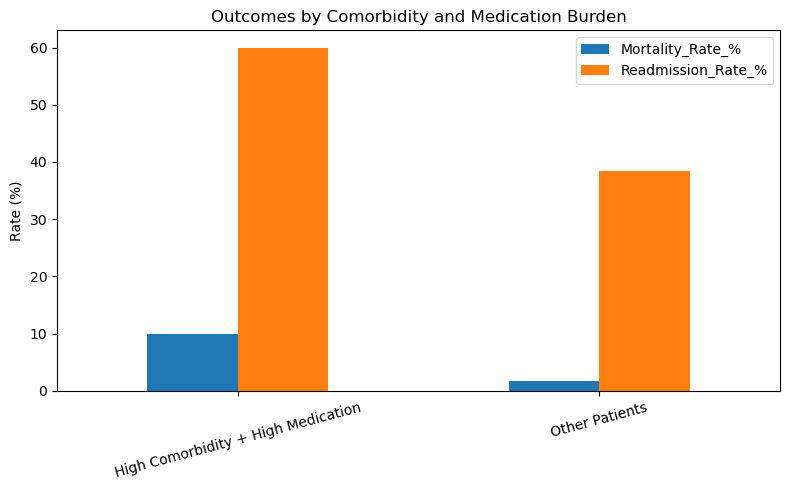

In [8]:
q19_summary[
    ["Mortality_Rate_%", "Readmission_Rate_%"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Outcomes by Comorbidity and Medication Burden")
plt.ylabel("Rate (%)")
plt.xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients with both high comorbidity burden and high medication use had substantially worse observed outcomes. Using 9 medications as the high-medication cutoff, this combined high-burden group had an average CCI score of 5.10 and 10.20 medications. Their 28-day mortality was 10.0%, compared with 1.8% among other patients, while 6-month readmission was 60.0% compared with 38.39%. However, only 10 patients met the combined high-burden definition, so these percentages should be interpreted cautiously.<br><b>What this means:</b> patients with both very high comorbidity and medication burden may represent an especially complex high-risk group that could benefit from closer medication review and follow-up, but the small group size means this finding should be validated before being used as a clinical rule.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q20. Guideline medication count – Is the number of guideline-directed heart-failure medications received at discharge associated with differences in readmission and mortality outcomes?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>Metoprolol Succinate Sustained-release tablet, metoprolol tartrate injection, Benazepril hydrochloride tablet, Valsartan Dispersible tablet, Spironolactone tablet, death_within_28_days, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The cleaned dataset contains prescription indicators that can be grouped into beta-blocker, ACE inhibitor/ARB and spironolactone categories. We count how many of these three medication groups are recorded for each patient and compare mortality and readmission across patients receiving zero, one, two or three groups. This allows us to examine whether the number of recorded heart-failure medication groups is associated with differences in observed outcomes. Because this is observational data, any relationship should be interpreted as an association and not as proof that receiving more or fewer medications caused the outcome.</b></i></p>

In [9]:
# Q20: Guideline-directed medication count

q20 = df.copy()

beta_cols = [
    "Metoprolol Succinate Sustained-release tablet",
    "metoprolol tartrate injection"
]

ace_arb_cols = [
    "Benazepril hydrochloride tablet",
    "Valsartan Dispersible tablet"
]

spironolactone_col = "Spironolactone tablet"

# Beta-blocker
q20["Beta_Blocker"] = (
    q20[beta_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .gt(0)
    .any(axis=1)
    .astype(int)
)

# ACE inhibitor / ARB
q20["ACE_ARB"] = (
    q20[ace_arb_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .gt(0)
    .any(axis=1)
    .astype(int)
)

# Spironolactone
q20["Spironolactone"] = (
    pd.to_numeric(
        q20[spironolactone_col],
        errors="coerce"
    )
    .fillna(0)
    .gt(0)
    .astype(int)
)

# Number of therapy groups: 0–3
q20["Guideline_Med_Count"] = (
    q20["Beta_Blocker"] +
    q20["ACE_ARB"] +
    q20["Spironolactone"]
)

q20_summary = q20.groupby(
    "Guideline_Med_Count"
).agg(
    Patients=("inpatient_number", "count"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q20_summary["Mortality_Rate_%"] = (
    q20_summary["Mortality_Rate"] * 100
).round(2)

q20_summary["Readmission_Rate_%"] = (
    q20_summary["Readmission_Rate"] * 100
).round(2)

display(q20_summary)

,Patients,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
Guideline_Med_Count,,,,,
0,120,0.100000,0.250000,10.00,25.00
1,800,0.022500,0.375000,2.25,37.50
2,699,0.010014,0.427754,1.00,42.78
3,389,0.000000,0.370180,0.00,37.02


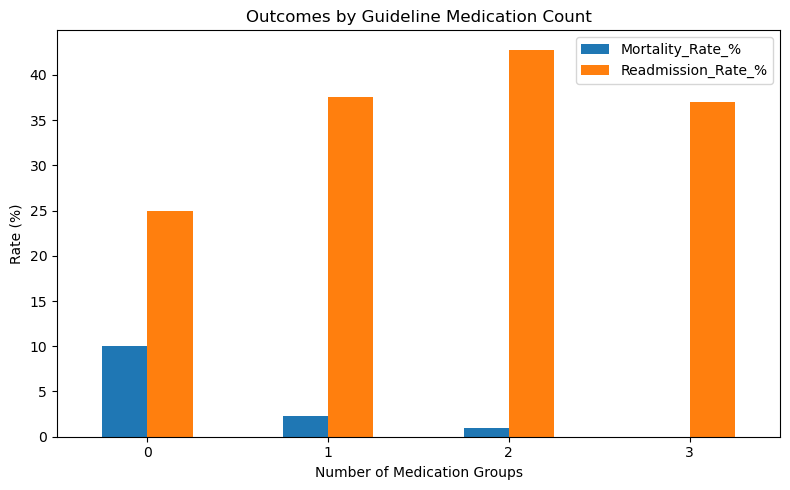

In [10]:
q20_summary[
    ["Mortality_Rate_%", "Readmission_Rate_%"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Outcomes by Guideline Medication Count")
plt.xlabel("Number of Medication Groups")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>28-day mortality decreased steadily as the number of recorded heart-failure medication groups increased: mortality was 10.0% with no medication groups, 2.25% with one group, 1.0% with two groups and 0% with all three groups. The readmission pattern was different: 6-month readmission was 25.0% with no groups, 37.5% with one, 42.78% with two and 37.02% with three. Therefore, the strongest descriptive pattern is seen for mortality rather than readmission.<br><b>What this means:</b> patients with more recorded heart-failure medication groups had lower observed 28-day mortality, but this is an observational association and does not prove that increasing medication count caused lower mortality. Differences in disease severity, eligibility for treatment and prescribing patterns may also explain the result.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q21. Inotrope use – Do patients receiving inotropic medications such as milrinone, dobutamine or deslanoside have greater markers of disease severity and worse outcomes than patients who do not receive these medications?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>Milrinone injection, Dobutamine hydrochloride injection, Deslanoside injection, nyha_cardiac_function_classification, lvef, brain_natriuretic_peptide, high_sensitivity_troponin, death_within_28_days, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Inotropic medications such as milrinone, dobutamine and deslanoside may be used in patients with more severe cardiac dysfunction. We therefore compare patients with recorded inotrope use against those without recorded use using NYHA class, LVEF, BNP, troponin, mortality and readmission. If inotrope users show more severe cardiac markers and poorer outcomes, this would identify them as a higher-severity subgroup. It would not demonstrate that the medications caused the poorer outcomes because sicker patients may be more likely to receive these drugs.</b></i></p>

In [11]:
# Q21: Inotrope use

q21 = df.copy()

inotrope_cols = [
    "Milrinone injection",
    "Dobutamine hydrochloride injection",
    "Deslanoside injection"
]

q21["Inotrope_Use"] = (
    q21[inotrope_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .gt(0)
    .any(axis=1)
    .astype(int)
)

q21["Inotrope_Group"] = q21[
    "Inotrope_Use"
].map({
    0: "No Inotrope",
    1: "Inotrope"
})

q21_summary = q21.groupby(
    "Inotrope_Group"
).agg(
    Patients=("inpatient_number", "count"),
    Avg_LVEF=("lvef", "mean"),
    Avg_BNP=("brain_natriuretic_peptide", "mean"),
    Avg_Troponin=("high_sensitivity_troponin", "mean"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q21_summary["Mortality_Rate_%"] = (
    q21_summary["Mortality_Rate"] * 100
).round(2)

q21_summary["Readmission_Rate_%"] = (
    q21_summary["Readmission_Rate"] * 100
).round(2)

display(q21_summary.round(2))

,Patients,Avg_LVEF,Avg_BNP,Avg_Troponin,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
Inotrope_Group,,,,,,,,
Inotrope,1249,48.44,1589.71,379.57,0.02,0.41,2.16,41.39
No Inotrope,759,54.28,762.89,114.72,0.01,0.34,1.32,33.73


In [12]:
nyha_inotrope = pd.crosstab(
    q21["Inotrope_Group"],
    q21["nyha_cardiac_function_classification"],
    normalize="index"
) * 100

print("NYHA Distribution (%)")
display(nyha_inotrope.round(2))

NYHA Distribution (%)


nyha_cardiac_function_classification,2,3,4
Inotrope_Group,,,
Inotrope,14.09,47.80,38.11
No Inotrope,23.32,58.23,18.45


<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients receiving inotropes showed a substantially more severe cardiac profile. Their average LVEF was lower at 48.44% compared with 54.28% in patients without inotropes, while average BNP was more than twice as high (1,589.71 vs 762.89) and average troponin was more than three times as high (379.57 vs 114.72). NYHA class IV was also much more common among inotrope users (38.11% vs 18.45%). Their 28-day mortality was 2.16% compared with 1.32%, and 6-month readmission was 41.39% compared with 33.73%.<br><b>What this means:</b> inotrope use identifies a group with greater cardiac dysfunction, biomarker elevation and poorer observed outcomes. This should mainly be interpreted as a marker of disease severity rather than evidence that inotropes themselves caused the worse outcomes.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q22. Blood pressure and shock index – Are lower systolic blood pressure and higher admission shock index associated with increased risk of death?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>pulse, systolic_blood_pressure, death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Derived variable:</b> <code>Shock Index = pulse / systolic_blood_pressure</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Blood pressure and heart rate provide information about cardiovascular stability. A patient with a relatively high pulse and low systolic blood pressure will have a higher shock index, which can indicate greater hemodynamic stress. We calculate shock index from the available pulse and systolic blood-pressure measurements and compare systolic pressure and shock index between patients who survived and those who died. We also divide shock index into data-based groups to examine whether observed mortality rises as the shock index increases.</b></i></p>

In [13]:
# Q22: Blood pressure and shock index

q22 = df[
    [
        "inpatient_number",
        "pulse",
        "systolic_blood_pressure",
        "death_within_28_days"
    ]
].copy()

q22["pulse"] = pd.to_numeric(
    q22["pulse"],
    errors="coerce"
)

q22["systolic_blood_pressure"] = pd.to_numeric(
    q22["systolic_blood_pressure"],
    errors="coerce"
)

# Remove impossible zero/negative BP values
q22.loc[
    q22["systolic_blood_pressure"] <= 0,
    "systolic_blood_pressure"
] = np.nan

# Calculate shock index
q22["Shock_Index"] = (
    q22["pulse"] /
    q22["systolic_blood_pressure"]
)

# Compare patients by mortality outcome
q22_summary = q22.groupby(
    "death_within_28_days"
).agg(
    Patients=("inpatient_number", "count"),
    Avg_Systolic_BP=("systolic_blood_pressure", "mean"),
    Median_Systolic_BP=("systolic_blood_pressure", "median"),
    Avg_Shock_Index=("Shock_Index", "mean"),
    Median_Shock_Index=("Shock_Index", "median")
)

display(q22_summary.round(3))

,Patients,Avg_Systolic_BP,Median_Systolic_BP,Avg_Shock_Index,Median_Shock_Index
death_within_28_days,,,,,
0,1971,131.378,130.0,0.668,0.636
1,37,126.417,127.0,0.734,0.689


In [14]:
q22["Shock_Index_Group"] = pd.qcut(
    q22["Shock_Index"],
    q=4,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4 - Highest"
    ],
    duplicates="drop"
)

shock_summary = q22.groupby(
    "Shock_Index_Group",
    observed=False
).agg(
    Patients=("inpatient_number", "count"),
    Deaths=("death_within_28_days", "sum"),
    Mortality_Rate=("death_within_28_days", "mean")
)

shock_summary["Mortality_Rate_%"] = (
    shock_summary["Mortality_Rate"] * 100
).round(2)

display(shock_summary)

,Patients,Deaths,Mortality_Rate,Mortality_Rate_%
Shock_Index_Group,,,,
Q1 - Lowest,502,7,0.013944,1.39
Q2,500,6,0.012000,1.20
Q3,500,11,0.022000,2.20
Q4 - Highest,501,12,0.023952,2.40


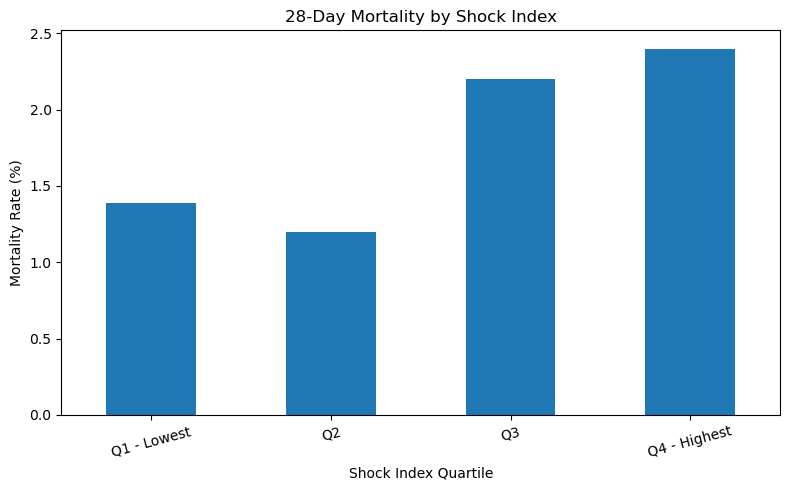

In [15]:
shock_summary["Mortality_Rate_%"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("28-Day Mortality by Shock Index")
plt.xlabel("Shock Index Quartile")
plt.ylabel("Mortality Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients who died within 28 days had lower average systolic blood pressure and a higher shock index than survivors. Average systolic pressure was 126.42 mmHg among patients who died compared with 131.38 mmHg among survivors, while average shock index was 0.734 compared with 0.668. The quartile analysis also shows a general increase in mortality at higher shock index levels: mortality was 1.39% in Q1, 1.20% in Q2, 2.20% in Q3 and 2.40% in the highest quartile.<br><b>What this means:</b> the combination of a faster pulse relative to systolic blood pressure may help identify patients with greater hemodynamic risk. The highest shock-index quartile had approximately twice the observed mortality of Q2, although statistical testing is needed before concluding that the difference is significant.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q23. BMI and albumin – Is lower BMI associated with lower albumin levels and worse patient outcomes, particularly among underweight patients?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>bmi, bmi_category, albumin, death_within_28_days, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>BMI provides a measure of body size, while albumin can provide information related to nutritional and overall health status. In patients with heart failure, a low BMI together with lower albumin may identify a subgroup with greater physiological vulnerability. We compare albumin, mortality and readmission across BMI categories and then specifically compare underweight patients with the remaining BMI groups. We also examine the relationship between BMI and albumin to determine whether lower body mass is associated with lower albumin and poorer observed outcomes in this dataset.</b></i></p>

In [16]:
# Q23: BMI, albumin and outcomes

q23 = df[
    [
        "inpatient_number",
        "bmi",
        "bmi_category",
        "albumin",
        "death_within_28_days",
        "re_admission_within_6_months"
    ]
].copy()

q23_summary = q23.groupby(
    "bmi_category"
).agg(
    Patients=("inpatient_number", "count"),
    Avg_BMI=("bmi", "mean"),
    Avg_Albumin=("albumin", "mean"),
    Median_Albumin=("albumin", "median"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q23_summary["Mortality_Rate_%"] = (
    q23_summary["Mortality_Rate"] * 100
).round(2)

q23_summary["Readmission_Rate_%"] = (
    q23_summary["Readmission_Rate"] * 100
).round(2)

display(q23_summary.round(2))

,Patients,Avg_BMI,Avg_Albumin,Median_Albumin,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
bmi_category,,,,,,,,
Normal,1184,21.36,36.53,36.7,0.02,0.37,1.86,37.42
Obese,66,32.06,35.94,37.4,0.00,0.38,0.00,37.88
Overweight,243,26.82,37.26,37.3,0.01,0.40,1.23,39.51
Underweight,507,17.09,36.24,36.4,0.02,0.41,2.37,41.03


In [17]:
correlation = q23[
    ["bmi", "albumin"]
].corr()

print("BMI and Albumin Correlation:")
display(correlation.round(3))

BMI and Albumin Correlation:


,bmi,albumin
bmi,1.000,0.054
albumin,0.054,1.000


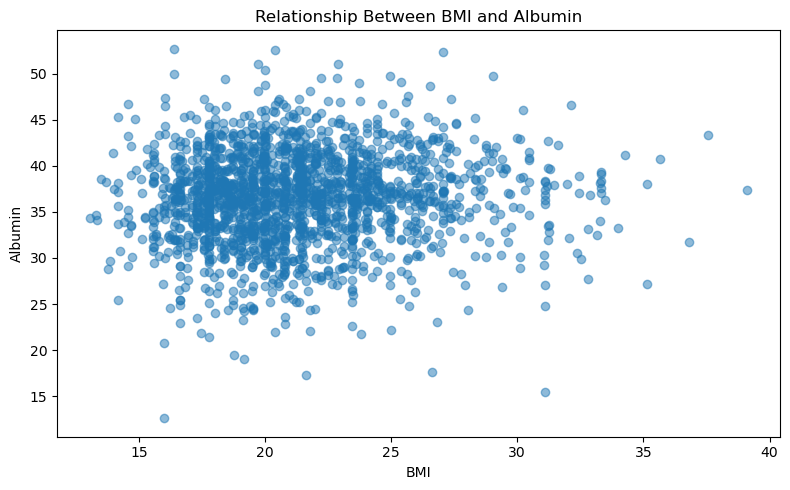

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    q23["bmi"],
    q23["albumin"],
    alpha=0.5
)

plt.title("Relationship Between BMI and Albumin")
plt.xlabel("BMI")
plt.ylabel("Albumin")
plt.tight_layout()
plt.show()

In [19]:
q23["Weight_Group"] = np.where(
    q23["bmi_category"] == "Underweight",
    "Underweight",
    "Other BMI Categories"
)

underweight_summary = q23.groupby(
    "Weight_Group"
).agg(
    Patients=("inpatient_number", "count"),
    Avg_Albumin=("albumin", "mean"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

underweight_summary["Mortality_Rate_%"] = (
    underweight_summary["Mortality_Rate"] * 100
).round(2)

underweight_summary["Readmission_Rate_%"] = (
    underweight_summary["Readmission_Rate"] * 100
).round(2)

display(underweight_summary.round(2))

,Patients,Avg_Albumin,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
Weight_Group,,,,,,
Other BMI Categories,1501,36.63,0.02,0.38,1.67,37.64
Underweight,507,36.24,0.02,0.41,2.37,41.03


<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Underweight patients had an average albumin level of 36.24 compared with 36.63 among all other BMI categories, but the overall correlation between BMI and albumin was only 0.054, showing almost no linear relationship. Underweight patients nevertheless had the highest observed 28-day mortality among the main BMI groups at 2.37%, compared with 1.86% in normal-weight patients, 1.23% in overweight patients and 0% in the small obese group. Their 6-month readmission rate was also higher at 41.03% compared with 37.64% among all other BMI categories combined.<br><b>What this means:</b> underweight patients show somewhat poorer observed outcomes, but lower albumin does not strongly explain this pattern because BMI and albumin are only very weakly correlated in this dataset. BMI may therefore be more useful as part of a broader risk profile rather than as a stand-alone nutritional risk marker.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q24. After stratifying patients by heart-failure severity and comorbidity burden, do age and gender groups differ in 6-month mortality?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b><br>
<code>agecat</code>, <code>gender</code>, <code>nyha_cardiac_function_classification</code>, <code>cci_score</code>, <code>death_within_6_months</code>
</p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Age and gender can appear related to mortality because demographic groups may also differ in heart-failure severity and comorbidity burden. NYHA class describes functional severity of heart failure, while the Charlson Comorbidity Index (CCI) summarizes major co-existing diseases. Therefore, mortality is first compared by age and gender, then examined within NYHA and CCI strata. This helps determine whether an age/gender pattern is still visible among patients with broadly similar severity and comorbidity burden.</b></i></p>

In [20]:
q24 = df[
    ["agecat", "gender", "nyha_cardiac_function_classification",
     "cci_score", "death_within_6_months"]
].dropna().copy()

# Overall age-gender mortality
age_gender = (
    q24.groupby(["agecat", "gender"], observed=True)["death_within_6_months"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)
age_gender["death_rate_%"] = age_gender["mean"] * 100

# CCI bands
q24["CCI group"] = pd.cut(
    q24["cci_score"],
    bins=[-0.1, 1, 2, np.inf],
    labels=["Low (0-1)", "Moderate (2)", "High (3+)"]
)

nyha_gender = (
    q24.groupby(["nyha_cardiac_function_classification", "gender"], observed=True)
    ["death_within_6_months"].agg(["count", "mean"]).reset_index()
)
nyha_gender["death_rate_%"] = nyha_gender["mean"] * 100

cci_gender = (
    q24.groupby(["CCI group", "gender"], observed=True)
    ["death_within_6_months"].agg(["count", "mean"]).reset_index()
)
cci_gender["death_rate_%"] = cci_gender["mean"] * 100

print("Overall 6-month mortality by age and gender")
display(age_gender[["agecat", "gender", "count", "death_rate_%"]].round(2))

print("\nMortality by gender within NYHA class")
display(nyha_gender[["nyha_cardiac_function_classification", "gender", "count", "death_rate_%"]].round(2))

print("\nMortality by gender within CCI burden")
display(cci_gender[["CCI group", "gender", "count", "death_rate_%"]].round(2))

Overall 6-month mortality by age and gender


,agecat,gender,count,death_rate_%
0,21-29,Female,3,0.00
1,21-29,Male,1,0.00
2,29-39,Female,5,0.00
3,29-39,Male,7,0.00
4,39-49,Female,18,5.56
5,39-49,Male,38,0.00
6,49-59,Female,51,3.92
7,49-59,Male,54,3.70
8,59-69,Female,190,2.11
9,59-69,Male,177,3.39



Mortality by gender within NYHA class


,nyha_cardiac_function_classification,gender,count,death_rate_%
0,2,Female,226,2.21
1,2,Male,126,3.17
2,3,Female,607,1.81
3,3,Male,430,1.63
4,4,Female,329,3.65
5,4,Male,285,6.32



Mortality by gender within CCI burden


,CCI group,gender,count,death_rate_%
0,Low (0-1),Female,502,1.99
1,Low (0-1),Male,324,3.40
2,Moderate (2),Female,414,2.66
3,Moderate (2),Male,285,2.81
4,High (3+),Female,246,2.85
5,High (3+),Male,232,4.31


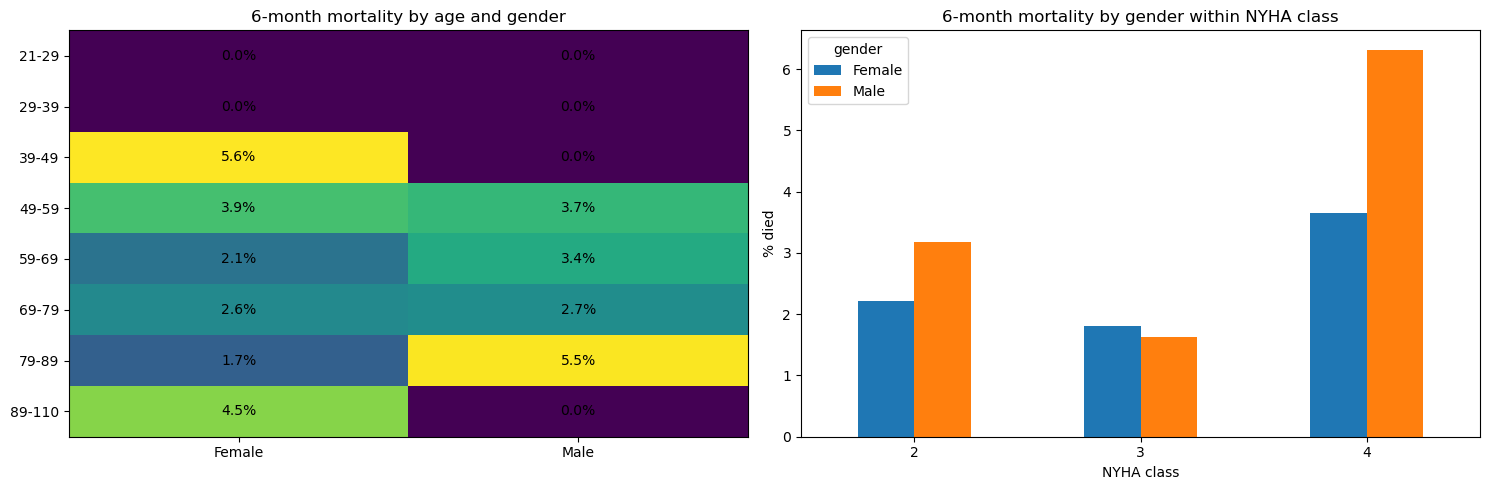

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

heat = age_gender.pivot(index="agecat", columns="gender", values="death_rate_%")
im = axes[0].imshow(heat.fillna(0), aspect="auto")
axes[0].set_title("6-month mortality by age and gender")
axes[0].set_xticks(range(len(heat.columns)), heat.columns)
axes[0].set_yticks(range(len(heat.index)), heat.index)
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        value = heat.iloc[i, j]
        if pd.notna(value):
            axes[0].text(j, i, f"{value:.1f}%", ha="center", va="center")

nyha_plot = nyha_gender.pivot(
    index="nyha_cardiac_function_classification",
    columns="gender",
    values="death_rate_%"
)
nyha_plot.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("6-month mortality by gender within NYHA class")
axes[1].set_xlabel("NYHA class")
axes[1].set_ylabel("% died")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>
The clearest age/gender signal is in older men: males aged 79–89 have about 5.5% 6-month mortality overall. After looking within severity strata, men with NYHA class IV have 6.3% mortality compared with 3.6% for women in the same class. Within high CCI burden (3+), mortality is also higher in men (4.3%) than women (2.8%). However, several younger age/gender groups are very small, so isolated percentages in those groups are unstable. The data therefore suggests that older men with severe heart failure and/or high comorbidity burden deserve particular attention, but age or gender alone should not be used as a risk rule.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q25. Do emergency admissions differ from planned admissions in length of stay, readmission and mortality outcomes?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b><br>
<code>admission_way</code>, <code>dischargeday</code>, <code>re_admission_within_6_months</code>, <code>death_within_6_months</code>
</p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Emergency admission may indicate acute deterioration, so these patients could be expected to stay longer or have worse outcomes. Length of stay is compared with both the mean and median because hospital-stay data can be skewed. Six-month readmission and mortality are then compared between Emergency and NonEmergency admissions. In this dataset, <code>NonEmergency</code> is used as the available comparison for planned/non-emergency admission.</b></i></p>

In [22]:
q25 = df[
    ["admission_way", "dischargeday",
     "re_admission_within_6_months", "death_within_6_months"]
].dropna().copy()

# Step 1: Summary statistics by admission type
summary25 = (
    q25.groupby("admission_way")
    .agg(
        patients=("admission_way", "size"),
        mean_stay=("dischargeday", "mean"),
        median_stay=("dischargeday", "median"),
        readmission_6m=("re_admission_within_6_months", "mean"),
        death_6m=("death_within_6_months", "mean")
    )
)

# Step 2: Convert outcome proportions to percentages
summary25["readmission_6m_%"] = (
    summary25["readmission_6m"] * 100
)

summary25["death_6m_%"] = (
    summary25["death_6m"] * 100
)

display(summary25.round(2))


# Step 3: Compare length of stay
em = q25.loc[
    q25["admission_way"] == "Emergency",
    "dischargeday"
]

ne = q25.loc[
    q25["admission_way"] == "NonEmergency",
    "dischargeday"
]

u, p_los = stats.mannwhitneyu(
    em,
    ne,
    alternative="two-sided"
)


# Step 4: Compare 6-month readmission
p_readm = chi_square(
    "admission_way",
    "re_admission_within_6_months",
    q25
)


# Step 5: Compare 6-month mortality
p_death = chi_square(
    "admission_way",
    "death_within_6_months",
    q25
)


# Step 6: Display statistical-test results
print(
    "Length-of-stay difference p =",
    p_text(p_los)
)

print(
    "6-month readmission difference p =",
    p_text(p_readm)
)

print(
    "6-month mortality difference p =",
    p_text(p_death)
)

,patients,mean_stay,median_stay,readmission_6m,death_6m,readmission_6m_%,death_6m_%
admission_way,,,,,,,
Emergency,956,8.92,8.0,0.38,0.03,38.39,3.03
NonEmergency,1052,9.88,8.0,0.39,0.03,38.59,2.66


Length-of-stay difference p = 0.062
6-month readmission difference p = 0.962
6-month mortality difference p = 0.714


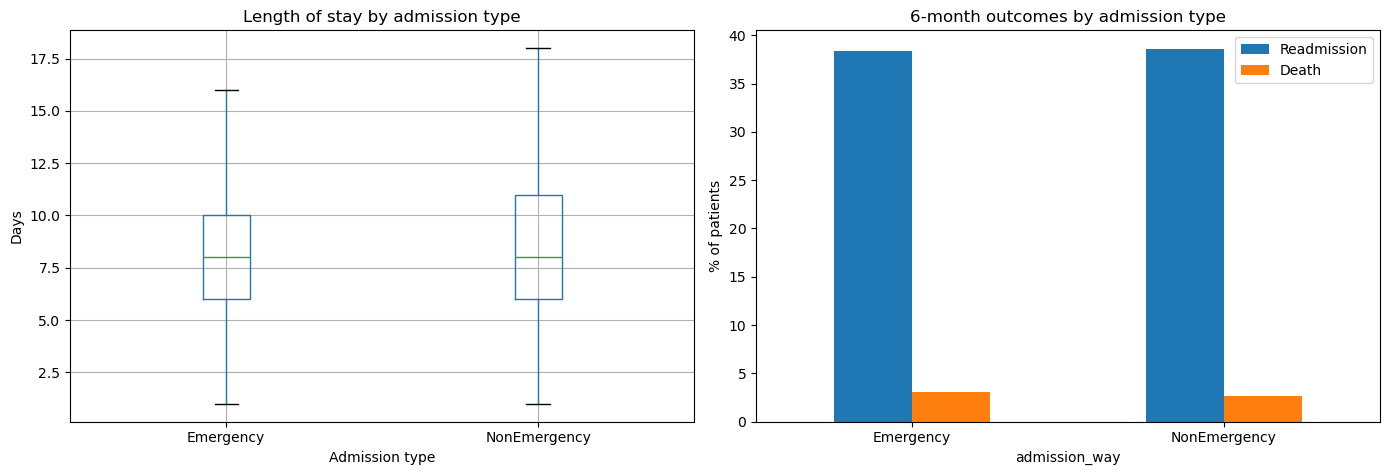

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q25.boxplot(column="dischargeday", by="admission_way", ax=axes[0], showfliers=False)
axes[0].set_title("Length of stay by admission type")
axes[0].set_xlabel("Admission type")
axes[0].set_ylabel("Days")
plt.suptitle("")

summary25[["readmission_6m_%", "death_6m_%"]].plot(
    kind="bar", ax=axes[1], rot=0
)
axes[1].set_title("6-month outcomes by admission type")
axes[1].set_ylabel("% of patients")
axes[1].legend(["Readmission", "Death"])

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Emergency admissions do not show clearly worse 6-month outcomes in this dataset. Both Emergency and NonEmergency patients have a median stay of 8 days, while the mean stay is slightly longer for NonEmergency admissions (9.88 vs 8.92 days). Six-month readmission is almost identical (38.4% vs 38.6%; p = 0.962), and mortality is also similar (3.0% vs 2.7%; p = 0.714). The difference in length of stay is also not statistically significant (p = 0.062). Therefore, admission type alone does not appear to distinguish higher-risk patients in this dataset.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q26. Is a very short hospital stay associated with earlier readmission or emergency return within 6 months?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b><br>
<code>dischargeday</code>, <code>re_admission_within_6_months</code>, <code>readmission_time_days_from_admission</code>, <code>return_to_emergency_department_within_6_months</code>, <code>time_to_emergency_department_within_6_months</code>
</p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>A very short stay can raise concern about premature discharge, but longer stays can also identify sicker or more complex patients. Hospital stay is therefore grouped into 1–3, 4–7, 8–14 and 15+ days. For each group, both the percentage returning within 6 months and the median time to readmission/ED return are compared. This distinguishes frequency of return from how soon the return occurs.</b></i></p>

In [24]:
q26 = df[
    ["dischargeday", "re_admission_within_6_months",
     "readmission_time_days_from_admission",
     "return_to_emergency_department_within_6_months",
     "time_to_emergency_department_within_6_months"]
].copy()

q26["LOS group"] = pd.cut(
    q26["dischargeday"],
    bins=[0, 3, 7, 14, np.inf],
    labels=["1-3 days", "4-7 days", "8-14 days", "15+ days"]
)

los26 = (
    q26.groupby("LOS group", observed=True)
    .agg(
        patients=("dischargeday", "size"),
        readmission_6m=("re_admission_within_6_months", "mean"),
        ed_return_6m=("return_to_emergency_department_within_6_months", "mean"),
        median_days_to_readmission=("readmission_time_days_from_admission", "median"),
        median_days_to_ed_return=("time_to_emergency_department_within_6_months", "median")
    )
)

los26["readmission_6m_%"] = los26["readmission_6m"] * 100
los26["ed_return_6m_%"] = los26["ed_return_6m"] * 100
display(los26.round(1))

,patients,readmission_6m,ed_return_6m,median_days_to_readmission,median_days_to_ed_return,readmission_6m_%,ed_return_6m_%
LOS group,,,,,,,
1-3 days,136,0.2,0.2,98.5,102.5,19.9,20.7
4-7 days,829,0.4,0.4,89.0,89.0,36.1,36.6
8-14 days,815,0.4,0.4,82.5,82.0,41.5,41.1
15+ days,228,0.5,0.5,68.5,68.5,47.8,47.8


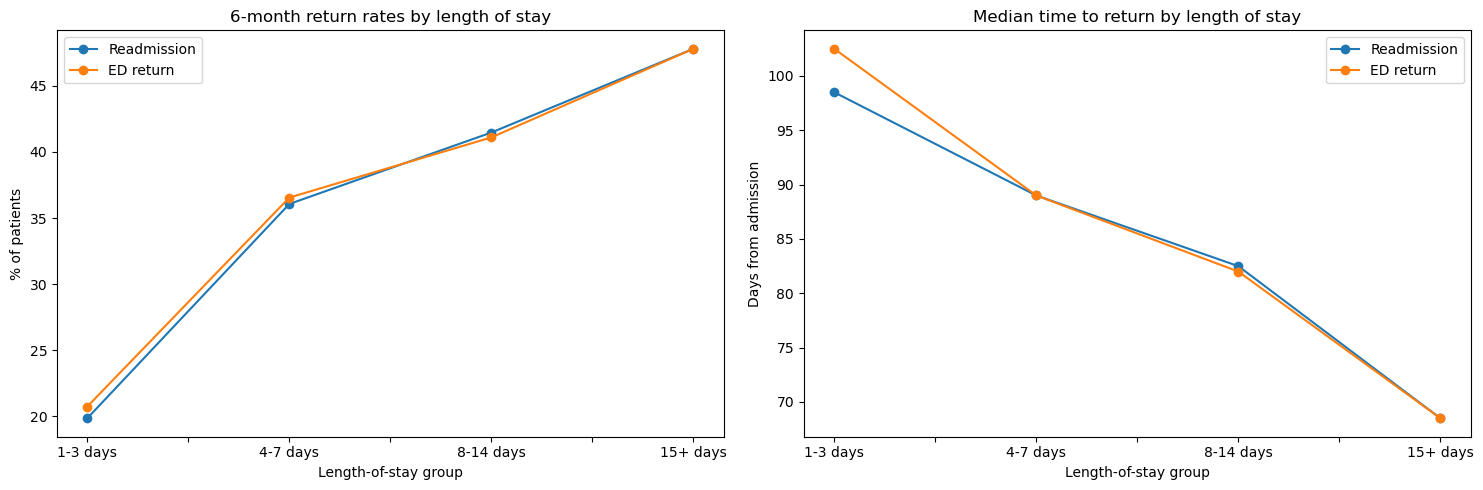

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

los26[["readmission_6m_%", "ed_return_6m_%"]].plot(
    kind="line", marker="o", ax=axes[0]
)
axes[0].set_title("6-month return rates by length of stay")
axes[0].set_ylabel("% of patients")
axes[0].set_xlabel("Length-of-stay group")
axes[0].legend(["Readmission", "ED return"])

los26[["median_days_to_readmission", "median_days_to_ed_return"]].plot(
    kind="line", marker="o", ax=axes[1]
)
axes[1].set_title("Median time to return by length of stay")
axes[1].set_ylabel("Days from admission")
axes[1].set_xlabel("Length-of-stay group")
axes[1].legend(["Readmission", "ED return"])

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>
Very short stays are not associated with more or earlier returns in this dataset. Patients staying 1–3 days have the lowest 6-month readmission (19.9%) and ED-return rate (20.7%), with median return times around 99–103 days. In contrast, patients staying 15+ days have the highest readmission and ED-return rates (both 47.8%) and return sooner, with a median of about 68.5 days. Longer stay therefore appears to be a marker of greater clinical complexity rather than evidence that short-stay patients were discharged too early.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q27. Do readmission and emergency-return rates differ according to discharge destination?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b><br>
<code>destinationdischarge</code>, <code>re_admission_within_6_months</code>, <code>return_to_emergency_department_within_6_months</code>
</p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Discharge destination can indicate how much support a patient needs after hospitalization. Patients going home, to a healthcare facility, or to an unknown destination may have different post-discharge risks. Readmission and ED-return rates are compared across destinations. Patients recorded as <code>Died</code> are shown separately but should not be interpreted as a normal post-discharge destination when planning transitional care.</b></i></p>

In [25]:
q27 = df[
    ["destinationdischarge",
     "re_admission_within_6_months",
     "return_to_emergency_department_within_6_months"]
].dropna().copy()


# Step 1: Calculate outcomes by discharge destination
dest27 = (
    q27.groupby("destinationdischarge")
    .agg(
        patients=("destinationdischarge", "size"),
        readmission_6m=(
            "re_admission_within_6_months",
            "mean"
        ),
        ed_return_6m=(
            "return_to_emergency_department_within_6_months",
            "mean"
        )
    )
)


# Step 2: Convert proportions to percentages
dest27["readmission_6m_%"] = (
    dest27["readmission_6m"] * 100
)

dest27["ed_return_6m_%"] = (
    dest27["ed_return_6m"] * 100
)

display(dest27.round(1))


# Step 3: Chi-square test for readmission
readmission_table = pd.crosstab(
    q27["destinationdischarge"],
    q27["re_admission_within_6_months"]
)

chi2_readm, p_readm, dof_readm, expected_readm = (
    stats.chi2_contingency(readmission_table)
)


# Step 4: Chi-square test for ED return
ed_table = pd.crosstab(
    q27["destinationdischarge"],
    q27["return_to_emergency_department_within_6_months"]
)

chi2_ed, p_ed, dof_ed, expected_ed = (
    stats.chi2_contingency(ed_table)
)


# Step 5: Display statistical-test results
print(
    "Readmission difference by destination p =",
    round(p_readm, 3)
)

print(
    "ED-return difference by destination p =",
    round(p_ed, 3)
)

,patients,readmission_6m,ed_return_6m,readmission_6m_%,ed_return_6m_%
destinationdischarge,,,,,
Died,14,0.0,0.0,0.0,0.0
HealthcareFacility,438,0.4,0.4,41.1,40.6
Home,1344,0.4,0.4,39.7,40.0
Unknown,211,0.3,0.3,28.4,28.4


Readmission difference by destination p = 0.0
ED-return difference by destination p = 0.0


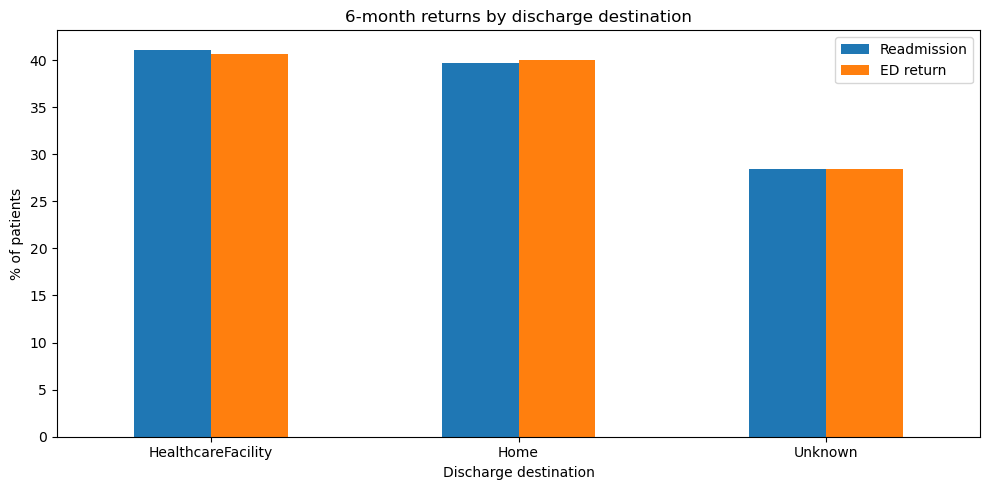

In [26]:
plot27 = dest27.drop(index="Died", errors="ignore")

ax = plot27[["readmission_6m_%", "ed_return_6m_%"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)
ax.set_title("6-month returns by discharge destination")
ax.set_ylabel("% of patients")
ax.set_xlabel("Discharge destination")
ax.legend(["Readmission", "ED return"])
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Among living discharge groups, patients discharged to a HealthcareFacility have the highest observed 6-month readmission rate (41.1%) and ED-return rate (40.6%). Home-discharged patients are very similar, with 39.7% readmission and 40.0% ED return, while the Unknown group has lower rates of about 28.4%. The overall Chi-square tests indicate that return outcomes differ across the recorded discharge-destination categories (p &lt; 0.001), although the difference between Home and HealthcareFacility itself is small. Discharge destination therefore provides useful risk context but should not be interpreted as causing subsequent return.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q28. Are patients with dementia, previous stroke, paralysis or reduced consciousness more likely to have non-home discharge destinations and higher mortality?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b><br>
<code>dementia</code>, <code>cerebrovascular_disease</code>, <code>hemiplegia</code>, <code>consciousness</code>, <code>destinationdischarge</code>, <code>death_within_6_months</code>
</p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Neurologic and cognitive problems can reduce a patient's ability to manage medicines, mobility and self-care after discharge. Dementia represents cognitive impairment; cerebrovascular disease is used as the available indicator of previous stroke/cerebrovascular disease; hemiplegia represents paralysis; and any consciousness level other than <code>Clear</code> is treated as reduced consciousness. We compare non-home discharge and 6-month mortality for each factor and for patients with at least one of these neurologic-risk features.</b></i></p>

In [27]:
q28 = df[
    ["dementia", "cerebrovascular_disease", "hemiplegia", "consciousness",
     "destinationdischarge", "death_within_6_months"]
].dropna().copy()

q28["reduced_consciousness"] = (q28["consciousness"] != "Clear").astype(int)
q28["non_home_discharge"] = (q28["destinationdischarge"] != "Home").astype(int)

risk_cols = ["dementia", "cerebrovascular_disease", "hemiplegia", "reduced_consciousness"]
q28["neurologic_risk_count"] = q28[risk_cols].sum(axis=1)
q28["any_neurologic_risk"] = (q28["neurologic_risk_count"] > 0).astype(int)

rows = []
for col in risk_cols + ["any_neurologic_risk"]:
    temp = q28.groupby(col).agg(
        patients=(col, "size"),
        non_home=("non_home_discharge", "mean"),
        death_6m=("death_within_6_months", "mean")
    )
    if 1 in temp.index:
        rows.append([
            col,
            int(temp.loc[1, "patients"]),
            temp.loc[1, "non_home"] * 100,
            temp.loc[1, "death_6m"] * 100
        ])

neuro28 = pd.DataFrame(
    rows, columns=["risk_feature", "patients", "non_home_%", "death_6m_%"]
)
display(neuro28.round(1))

print("\nAny neurologic-risk feature vs none")
display(
    q28.groupby("any_neurologic_risk")
    .agg(
        patients=("any_neurologic_risk", "size"),
        non_home=("non_home_discharge", "mean"),
        death_6m=("death_within_6_months", "mean")
    ).assign(
        non_home_pct=lambda x: x["non_home"] * 100,
        death_pct=lambda x: x["death_6m"] * 100
    ).round(3)
)

,risk_feature,patients,non_home_%,death_6m_%
0,dementia,115,38.3,0.9
1,cerebrovascular_disease,150,40.0,4.0
2,hemiplegia,12,75.0,0.0
3,reduced_consciousness,34,47.1,44.1
4,any_neurologic_risk,288,39.2,6.2



Any neurologic-risk feature vs none


,patients,non_home,death_6m,non_home_pct,death_pct
any_neurologic_risk,,,,,
0,1720,0.320,0.023,32.035,2.267
1,288,0.392,0.062,39.236,6.250


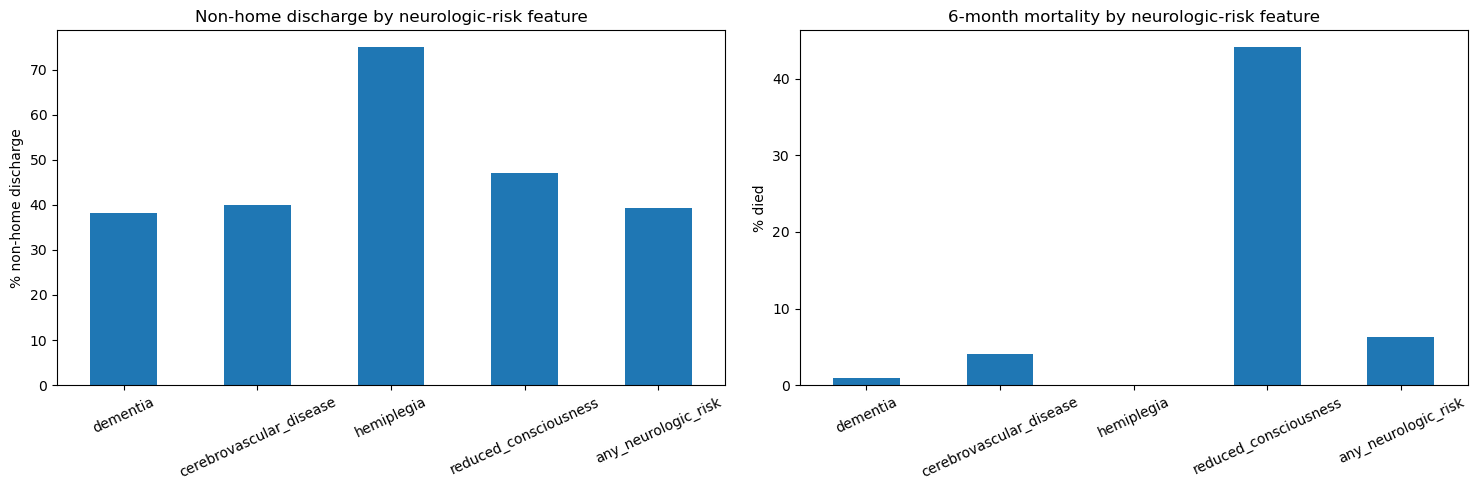

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

neuro28.set_index("risk_feature")["non_home_%"].plot(kind="bar", ax=axes[0], rot=25)
axes[0].set_title("Non-home discharge by neurologic-risk feature")
axes[0].set_ylabel("% non-home discharge")
axes[0].set_xlabel("")

neuro28.set_index("risk_feature")["death_6m_%"].plot(kind="bar", ax=axes[1], rot=25)
axes[1].set_title("6-month mortality by neurologic-risk feature")
axes[1].set_ylabel("% died")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>
Patients with at least one neurologic-risk feature are more often discharged somewhere other than home (39.2% vs 32.0%) and have higher 6-month mortality (6.3% vs 2.3%). Reduced consciousness is the strongest observed warning sign: 47.1% have a non-home discharge and 44.1% die within 6 months, although this group contains only 34 patients. Hemiplegia also has a very high non-home discharge rate (75%), but there are only 12 such patients. Dementia alone does not show higher mortality here. The combined neurologic profile is therefore more useful than assuming every individual neurologic condition carries the same risk.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q29. Which combination of biomarkers, heart-failure severity measures, comorbidities and clinical characteristics is most strongly associated with 6-month readmission or mortality, and can these factors be combined into a data-driven high-risk profile to prioritize closer follow-up after discharge?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b><br>
<code>brain_natriuretic_peptide</code>, <code>high_sensitivity_troponin</code>, <code>hs_crp</code>, <code>albumin</code>, <code>sodium</code>, <code>creatinine_enzymatic_method</code>, <code>glomerular_filtration_rate</code>, <code>nyha_cardiac_function_classification</code>, <code>cci_score</code>, <code>lvef</code>, <code>systolic_blood_pressure</code>, <code>pulse</code>, <code>total_drugs</code>, <code>re_admission_within_6_months</code>, <code>death_within_6_months</code>
</p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Heart-failure outcomes are unlikely to be explained by one marker alone. This question combines biomarkers of cardiac stress/injury and inflammation, renal function, electrolytes, heart-failure severity, comorbidity, vital signs and medication burden. A standardized logistic-regression model is used as an exploratory multivariable tool. Because all numeric predictors are standardized first, the absolute coefficient sizes can be compared to see which variables contribute most strongly within this model. Model probabilities are then divided into three equal-sized risk bands to test whether observed outcome rates rise from lower to higher predicted risk. This is an exploratory in-sample profile, not a validated clinical prediction score.</b></i></p>

In [29]:
# Step 1: Import required libraries
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score


# Step 2: Select clinical and biomarker features
features29 = [
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "hs_crp",
    "albumin",
    "sodium",
    "creatinine_enzymatic_method",
    "glomerular_filtration_rate",
    "nyha_cardiac_function_classification",
    "cci_score",
    "lvef",
    "systolic_blood_pressure",
    "pulse",
    "total_drugs"
]


# Step 3: Create readable labels
labels29 = {
    "brain_natriuretic_peptide": "BNP",
    "high_sensitivity_troponin": "Troponin",
    "hs_crp": "hs-CRP",
    "albumin": "Albumin",
    "sodium": "Sodium",
    "creatinine_enzymatic_method": "Creatinine",
    "glomerular_filtration_rate": "GFR",
    "nyha_cardiac_function_classification": "NYHA",
    "cci_score": "CCI",
    "lvef": "LVEF",
    "systolic_blood_pressure": "Systolic BP",
    "pulse": "Pulse",
    "total_drugs": "Total drugs"
}


# Step 4: Create a function to build the risk model
def fit_risk_model(outcome):

    X = df[features29]
    y = df[outcome]

    # Fill missing values, standardize variables,
    # and run logistic regression
    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )

    model.fit(X, y)


    # Step 5: Calculate predicted probability
    probability = model.predict_proba(X)[:, 1]


    # Step 6: Get standardized coefficients
    coefficients = pd.Series(
        model[-1].coef_[0],
        index=features29
    ).sort_values(
        key=abs,
        ascending=False
    )


    # Step 7: Divide patients into risk groups
    bands = pd.qcut(
        probability,
        3,
        labels=["Lower", "Middle", "Higher"]
    )


    # Step 8: Calculate actual outcome rate
    # within each risk group
    observed = (
        pd.DataFrame({
            "risk_band": bands,
            "outcome": y
        })
        .groupby(
            "risk_band",
            observed=True
        )["outcome"]
        .agg(["count", "mean"])
    )

    observed["observed_rate_%"] = (
        observed["mean"] * 100
    )

    return (
        model,
        probability,
        coefficients,
        observed
    )


# Step 9: Build model for 6-month readmission
readm_model, readm_prob, readm_coef, readm_band = (
    fit_risk_model(
        "re_admission_within_6_months"
    )
)


# Step 10: Build model for 6-month mortality
death_model, death_prob, death_coef, death_band = (
    fit_risk_model(
        "death_within_6_months"
    )
)


# Step 11: Display strongest associations
print(
    "Strongest standardized associations "
    "with 6-month readmission"
)

display(
    readm_coef
    .rename(index=labels29)
    .head(8)
    .to_frame("standardized coefficient")
    .round(3)
)


print(
    "\nStrongest standardized associations "
    "with 6-month mortality"
)

display(
    death_coef
    .rename(index=labels29)
    .head(8)
    .to_frame("standardized coefficient")
    .round(3)
)


# Step 12: Compare observed outcomes
# across risk groups
print(
    "\nObserved outcomes across "
    "data-driven risk bands"
)

display(
    pd.DataFrame({
        "Readmission %":
            readm_band["observed_rate_%"],

        "Mortality %":
            death_band["observed_rate_%"]
    }).round(1)
)


# Step 13: Calculate exploratory AUC
print("\nExploratory in-sample AUC")

print(
    "Readmission:",
    round(
        roc_auc_score(
            df["re_admission_within_6_months"],
            readm_prob
        ),
        3
    )
)

print(
    "Mortality:",
    round(
        roc_auc_score(
            df["death_within_6_months"],
            death_prob
        ),
        3
    )
)

Strongest standardized associations with 6-month readmission


,standardized coefficient
Troponin,-0.290
NYHA,0.184
Total drugs,0.183
GFR,-0.156
Systolic BP,-0.128
CCI,0.128
Sodium,-0.120
Albumin,0.120



Strongest standardized associations with 6-month mortality


,standardized coefficient
BNP,0.461
Creatinine,0.291
Total drugs,-0.289
Sodium,-0.277
NYHA,0.249
hs-CRP,0.206
GFR,-0.194
CCI,-0.158



Observed outcomes across data-driven risk bands


,Readmission %,Mortality %
risk_band,,
Lower,27.2,0.4
Middle,37.8,1.9
Higher,50.5,6.1



Exploratory in-sample AUC
Readmission: 0.628
Mortality: 0.762


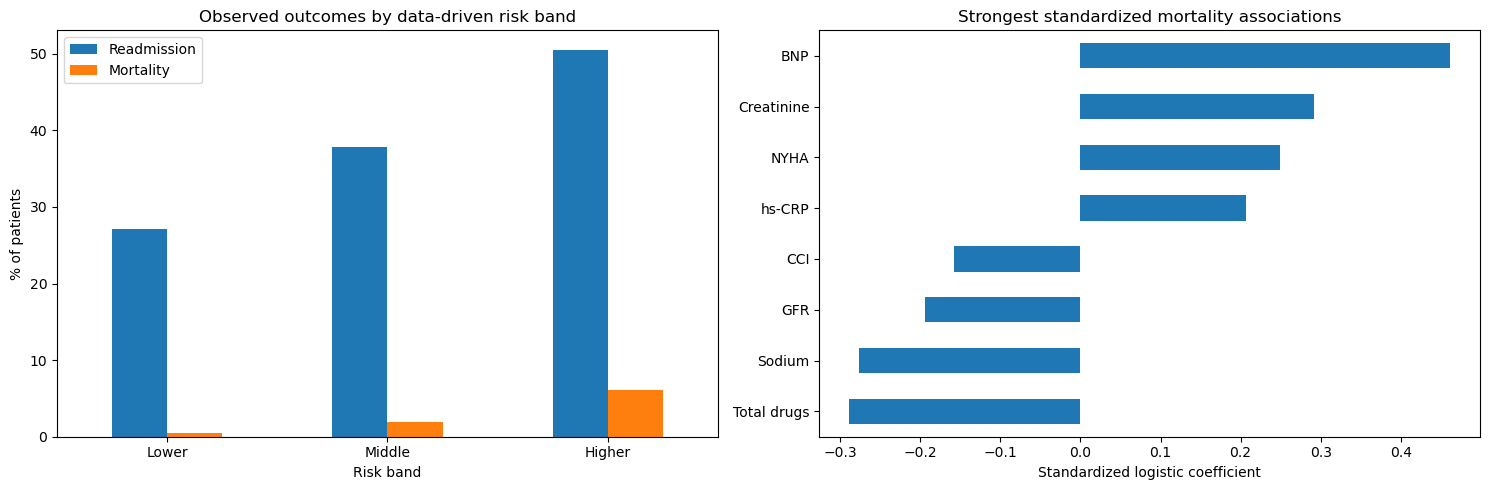

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pd.DataFrame({
    "Readmission": readm_band["observed_rate_%"],
    "Mortality": death_band["observed_rate_%"]
}).plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Observed outcomes by data-driven risk band")
axes[0].set_ylabel("% of patients")
axes[0].set_xlabel("Risk band")

top_death = death_coef.head(8).sort_values()
top_death.index = [labels29[x] for x in top_death.index]
top_death.plot(kind="barh", ax=axes[1])
axes[1].set_title("Strongest standardized mortality associations")
axes[1].set_xlabel("Standardized logistic coefficient")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The combined model identifies several variables associated with 6-month outcomes. For readmission, the largest standardized associations by absolute coefficient magnitude include troponin, NYHA class, total medication count, GFR, systolic BP, CCI and sodium. Some associations are positive and others negative, so coefficient direction should be considered rather than interpreting coefficient size alone. For mortality, higher BNP shows the strongest positive association, followed by higher creatinine and higher NYHA class, while lower sodium and lower GFR are also associated with greater predicted mortality risk. Observed outcomes increase clearly across the model-derived risk bands: readmission rises from 27.2% in the lower-risk group to 50.5% in the higher-risk group, while mortality rises from 0.4% to 6.1%. The in-sample AUC is 0.628 for readmission and 0.762 for mortality, indicating that the mortality model separates outcomes better than the readmission model in this dataset. Because these values are calculated on the same data used to fit the models, they should be considered exploratory rather than validated predictive performance.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q30. What clinical, biomarker, comorbidity, medication and discharge characteristics distinguish patients who repeatedly return to the hospital or emergency department within 6 months, and can these characteristics be used to develop a targeted case-management or transitional-care profile?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b><br>
<code>visit_times</code>, <code>return_to_emergency_department_within_6_months</code>, <code>time_to_emergency_department_within_6_months</code>, <code>nyha_cardiac_function_classification</code>, <code>cci_score</code>, <code>brain_natriuretic_peptide</code>, <code>high_sensitivity_troponin</code>, <code>hs_crp</code>, <code>albumin</code>, <code>sodium</code>, <code>creatinine_enzymatic_method</code>, <code>glomerular_filtration_rate</code>, <code>total_drugs</code>, selected medication columns, <code>destinationdischarge</code>, <code>dischargeday</code>
</p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Frequent returners may share a broader profile than simply having severe heart failure. Here a frequent returner is defined as a patient with more than one recorded visit or an ED return within 6 months. We compare heart-failure severity, comorbidity, biomarkers, renal function, medication burden, selected commonly used medicines, discharge destination and length of stay between frequent returners and other patients. Medication differences are interpreted as markers of treatment intensity/illness complexity, not as proof that the medicines cause return visits.</b></i></p>

In [31]:
q30 = df.copy()

q30["frequent_returner"] = (
    (q30["visit_times"] > 1) |
    (q30["return_to_emergency_department_within_6_months"] == 1)
).astype(int)

profile_cols = [
    "nyha_cardiac_function_classification", "cci_score",
    "brain_natriuretic_peptide", "high_sensitivity_troponin",
    "hs_crp", "albumin", "sodium", "creatinine_enzymatic_method",
    "glomerular_filtration_rate", "total_drugs", "dischargeday"
]

profile30 = q30.groupby("frequent_returner")[profile_cols].median().T
profile30.columns = ["Other patients", "Frequent returners"]
display(profile30.round(2))

print("\nFrequent returner count")
print(q30["frequent_returner"].value_counts().sort_index())
print("Frequent returner %:", round(q30["frequent_returner"].mean() * 100, 1))

print("\nMedian time to ED return among frequent returners:",
      round(q30.loc[q30["frequent_returner"] == 1,
                    "time_to_emergency_department_within_6_months"].median(), 1),
      "days")

destination30 = pd.crosstab(
    q30["destinationdischarge"],
    q30["frequent_returner"],
    normalize="index"
) * 100
destination30.columns = ["Other patients", "Frequent returners"]
display(destination30.round(1))

medications = [
    "Milrinone injection", "Digoxin tablet", "Furosemide tablet",
    "Furosemide injection", "Spironolactone tablet", "Torasemide tablet"
]

med30 = q30.groupby("frequent_returner")[medications].mean().T * 100
med30.columns = ["Other patients", "Frequent returners"]
med30["difference_pp"] = med30["Frequent returners"] - med30["Other patients"]
display(med30.sort_values("difference_pp", ascending=False).round(1))

,Other patients,Frequent returners
nyha_cardiac_function_classification,3.00,3.00
cci_score,2.00,2.00
brain_natriuretic_peptide,711.41,849.33
high_sensitivity_troponin,47.00,64.00
hs_crp,9.30,9.65
albumin,36.70,36.90
sodium,139.05,138.60
creatinine_enzymatic_method,83.00,92.80
glomerular_filtration_rate,68.63,58.68
total_drugs,8.00,8.00



Frequent returner count
frequent_returner
0    1151
1     857
Name: count, dtype: int64
Frequent returner %: 42.7

Median time to ED return among frequent returners: 73.0 days


,Other patients,Frequent returners
destinationdischarge,,
Died,92.9,7.1
HealthcareFacility,54.1,45.9
Home,56.2,43.8
Unknown,68.9,31.1


,Other patients,Frequent returners,difference_pp
Milrinone injection,31.5,40.3,8.8
Digoxin tablet,46.0,54.7,8.8
Furosemide tablet,78.5,86.0,7.5
Furosemide injection,83.1,88.9,5.9
Torasemide tablet,10.6,15.2,4.6
Spironolactone tablet,89.5,93.7,4.2


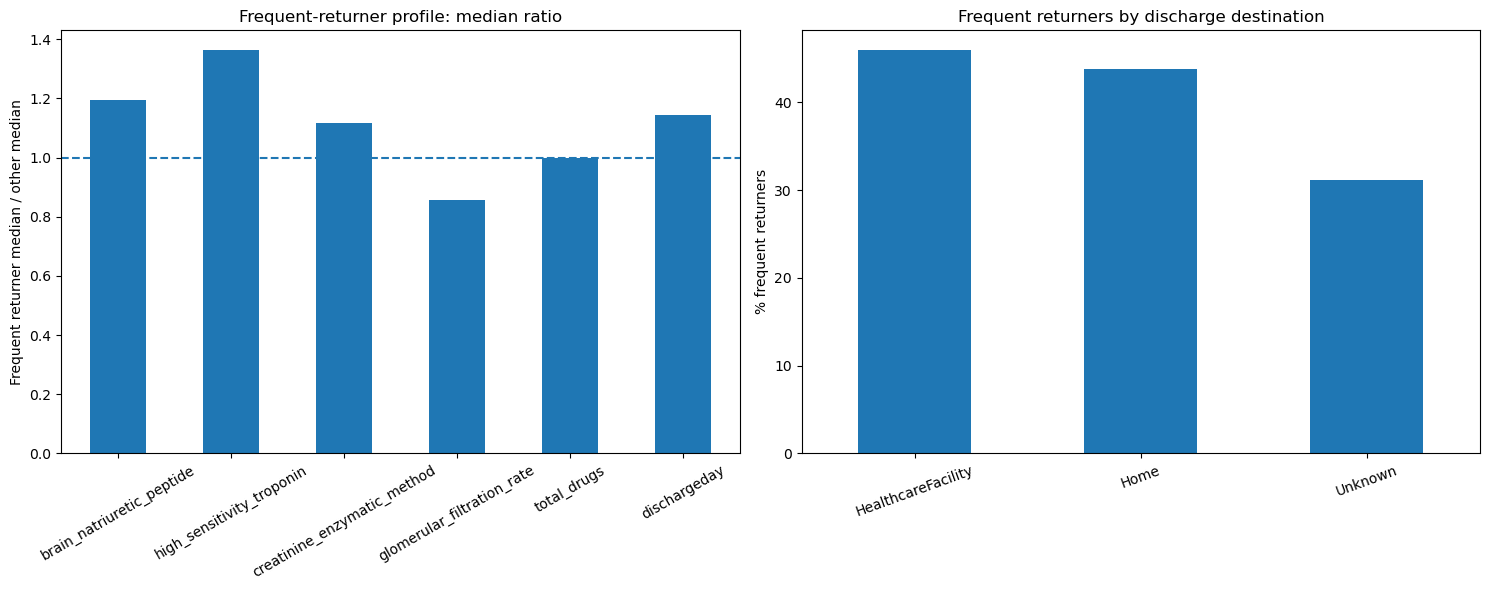

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Key biomarker/clinical medians as ratios to make different units comparable
ratio_cols = [
    "brain_natriuretic_peptide", "high_sensitivity_troponin",
    "creatinine_enzymatic_method", "glomerular_filtration_rate",
    "total_drugs", "dischargeday"
]
ratio = (
    q30.groupby("frequent_returner")[ratio_cols].median().T
)
ratio["Frequent / Other"] = ratio[1] / ratio[0]
ratio["Frequent / Other"].plot(kind="bar", ax=axes[0], rot=30)
axes[0].axhline(1, linestyle="--")
axes[0].set_title("Frequent-returner profile: median ratio")
axes[0].set_ylabel("Frequent returner median / other median")
axes[0].set_xlabel("")

destination30["Frequent returners"].drop(index="Died", errors="ignore").plot(
    kind="bar", ax=axes[1], rot=20
)
axes[1].set_title("Frequent returners by discharge destination")
axes[1].set_ylabel("% frequent returners")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>
Using the defined rule, 857 of 2,008 patients (42.7%) are frequent returners. Compared with other patients, they have higher median BNP (849 vs 711), troponin (64 vs 47), creatinine (92.8 vs 83), and lower median GFR (58.7 vs 68.6), suggesting greater cardiac and renal burden. Their median stay is also slightly longer (8 vs 7 days). Several intensive heart-failure medicines are used more often in frequent returners, including milrinone, digoxin and furosemide, which likely reflects greater illness/treatment complexity rather than a medication-caused return. Frequent-returner prevalence is highest among patients discharged to a HealthcareFacility (45.9%), followed by Home (43.8%), and their median ED-return time is about 73 days.</b></i></p>